# Encoding Model Scaling Laws Tutorial

This notebook is meant to provide a basic tutorial on how to use the data and models released for the paper "Scaling Laws for Language Encoding Models fMRI. As this is a scaling laws paper, be aware many of the files used by this notebook are ***large***. This notebook was tested on a machine with 128GB of RAM. We start with a few dependencies. The ridge_utils folder can be found in the same repository as this notebook.

In [1]:
#### Dependencies ####

import numpy as np
import logging
import sys
import time
import joblib
import matplotlib.pyplot as plt
import torch
import cortex # This dependency is pycortex, which enables the plotting of flatmaps. It can be disabled.
from cvxopt import matrix, solvers # Only necessary for the stacked model.
from transformers import AutoTokenizer, AutoModelForCausalLM # Only necessary for feature extraction.

# Repository imports
from ridge_utils.ridge import bootstrap_ridge
import ridge_utils.npp
from ridge_utils.util import make_delayed
from ridge_utils.dsutils import make_word_ds
from ridge_utils.DataSequence import DataSequence
from ridge_utils.tokenization_helpers import generate_efficient_feat_dicts_opt
from ridge_utils.tokenization_helpers import convert_to_feature_mats_opt

### Some extra helper functions

zscore = lambda v: (v - v.mean(0)) / v.std(0)
zscore.__doc__ = """Z-scores (standardizes) each column of [v]."""
zs = zscore

## Matrix corr -- find correlation between each column of c1 and the corresponding column of c2
mcorr = lambda c1, c2: (zs(c1) * zs(c2)).mean(0)
mcorr.__doc__ = """Matrix correlation. Find the correlation between each column of [c1] and the corresponding column of [c2]."""

### Ignore irrelevant warnings that muck up the notebook
import warnings

if not sys.warnoptions:
    warnings.simplefilter("ignore")

# Some parameters
NUM_VOX = 95556 # Number of voxels in the subject we plan to use
NUM_TRS = 790 # Number of TRs across 3 test stories
trim_start = 50 # Trim 50 TRs off the start of the story
trim_end = 5 # Trim 5 off the back
ndelays = 4 # We use 4 FIR delays (2 seconds, 4 seconds, 6 seconds, 8 seconds)
delays = range(1, ndelays + 1)

## Semantic Encoding Model with pre-generated features

We start by building a basic semantic encoding model from layer 33 of OPT-30B using the preexisting features, weights, and responses from the [Box folder](https://utexas.box.com/v/EncodingModelScalingLaws). We load the features, apply some basic processing steps, and then dot the features with the encoding model weights to get our voxelwise predictions. 

In [8]:
### Running a basic semantic encoding model built from OPT layer 33 ###

# We are going to test our model on one of our held-out stories, "wheretheressmoke".
Tstories = ['wheretheressmoke']

# Load the precomputed OPT model hidden states from the Box
# From semantic_features folder
features = joblib.load("downsampled_featureseqs_opt33b_layer33.jbl")

# Trim and zscore the model features
Tstim = np.nan_to_num(np.vstack([ridge_utils.npp.zs(features[story][trim_start:-trim_end]) for story in Tstories]))

# Add FIR delays
delTstim = make_delayed(Tstim, delays)

# Load the linear encoding model weights for subject S02
# From ridge_weights folder
wt = joblib.load("S3_opt33b_wts_layer33.jbl.jbl")

# Dot the weights with the features to get voxelwise model predictions
pred = np.dot(delTstim,  wt)

Let's do a basic noise ceiling analysis using our new predictions. We will use the method of [Schoppe et al.](https://www.frontiersin.org/articles/10.3389/fncom.2016.00010/full), as we did  in our paper. Below is a short code snippet that implements their noise ceiling estimation method. We load the ground truth responses and compare them to our predictions using this code. 

In [9]:
def spe_and_cc_norm(orig_data, data_pred, data_norm=True, max_flooring=None):
    '''
    Computes the signal power explained and the cc_norm of a model given the observed and predicted values
    Assumes normalization unless data_norm is set to False
    
    orig_data: 3D numpy array (trials, timepoints, voxels)
    
    data_pred: 2D numpy array (timepoints, voxels)
    
    data_norm: bool -> Set to False if not pre-normalized
    
    max_flooring: None/float (0-1) -> If not None, compute cc_norm in an alternate way that floors cc_max by max_flooring.
    This is helpful to clean up bad voxels that are not at all language selective.
    
    According to Schoppe: https://www.frontiersin.org/articles/10.3389/fncom.2016.00010/full
    '''
    y = np.mean(orig_data, axis=0)
    num_trials = len(orig_data)
    if not data_norm:
        variance_across_time = np.var(orig_data, axis=1, ddof=1)
        TP = np.mean(variance_across_time, axis=0)
    else:
        TP = np.zeros(orig_data.shape[2]) + 1
    SP = (1 / (num_trials-1)) * ((num_trials * np.var(y, axis=0, ddof=1)) - TP) 
    SPE_num = (np.var(y, axis=0, ddof=1) - np.var(y - data_pred, axis=0, ddof=1)) 
    SPE = (np.var(y, axis=0, ddof=1) - np.var(y - data_pred, axis=0, ddof=1)) / SP
    y_flip = np.swapaxes(y, axis1=0, axis2=1)
    data_flip = np.swapaxes(data_pred, axis1=0, axis2=1)
    covs = np.zeros(y_flip.shape[0])
    for i, row in enumerate(y_flip):
        covs[i] = np.cov(y_flip[i], data_flip[i])[0][1]
    cc_norm =  np.sqrt(1/SP) * (covs / np.sqrt(np.var(data_pred, axis=0, ddof=1)))
    cc_max = None
    if max_flooring is not None:
        cc_max = np.nan_to_num(1 / (np.sqrt(1 + ((1/num_trials) * ((TP/SP)-1)))))
        #cc_max = np.maximum(cc_max, np.zeros(cc_max.shape) + max_flooring)
        corrs = np.zeros(y_flip.shape[0])
        for i, row in enumerate(y_flip):
            corrs[i] = np.corrcoef(y_flip[i], data_flip[i])[0][1]
        cc_norm = corrs / cc_max
    return SPE, cc_norm, cc_max, corrs

# From responses folder
tensessions = joblib.load("tensessions_wheretheressmoke_S03.jbl")
SPE, cc_norm, cc_max, corrs_unnorm = spe_and_cc_norm(tensessions[:,40:,:], pred, max_flooring=0.25)

In [10]:
len(cc_max)

95556

In [6]:
# This is the average correlation per-voxel?
np.mean(corrs_unnorm) 

0.17161942089017293

In [3]:
acc = np.zeros(95556,)

Next, let's plot some simple performance metrics, like voxelwise correlation. These next few slides require Pycortex, you can skip them if you don't have it installed for our subjects on your machine. We assume here that you have the surface for UTS03 from our dataset in order to plot it. Here we filter voxels that are not language selective out by only selecting for voxels that have $cc_{max}$ > 0.35, and then we plot the resulting flatmap.

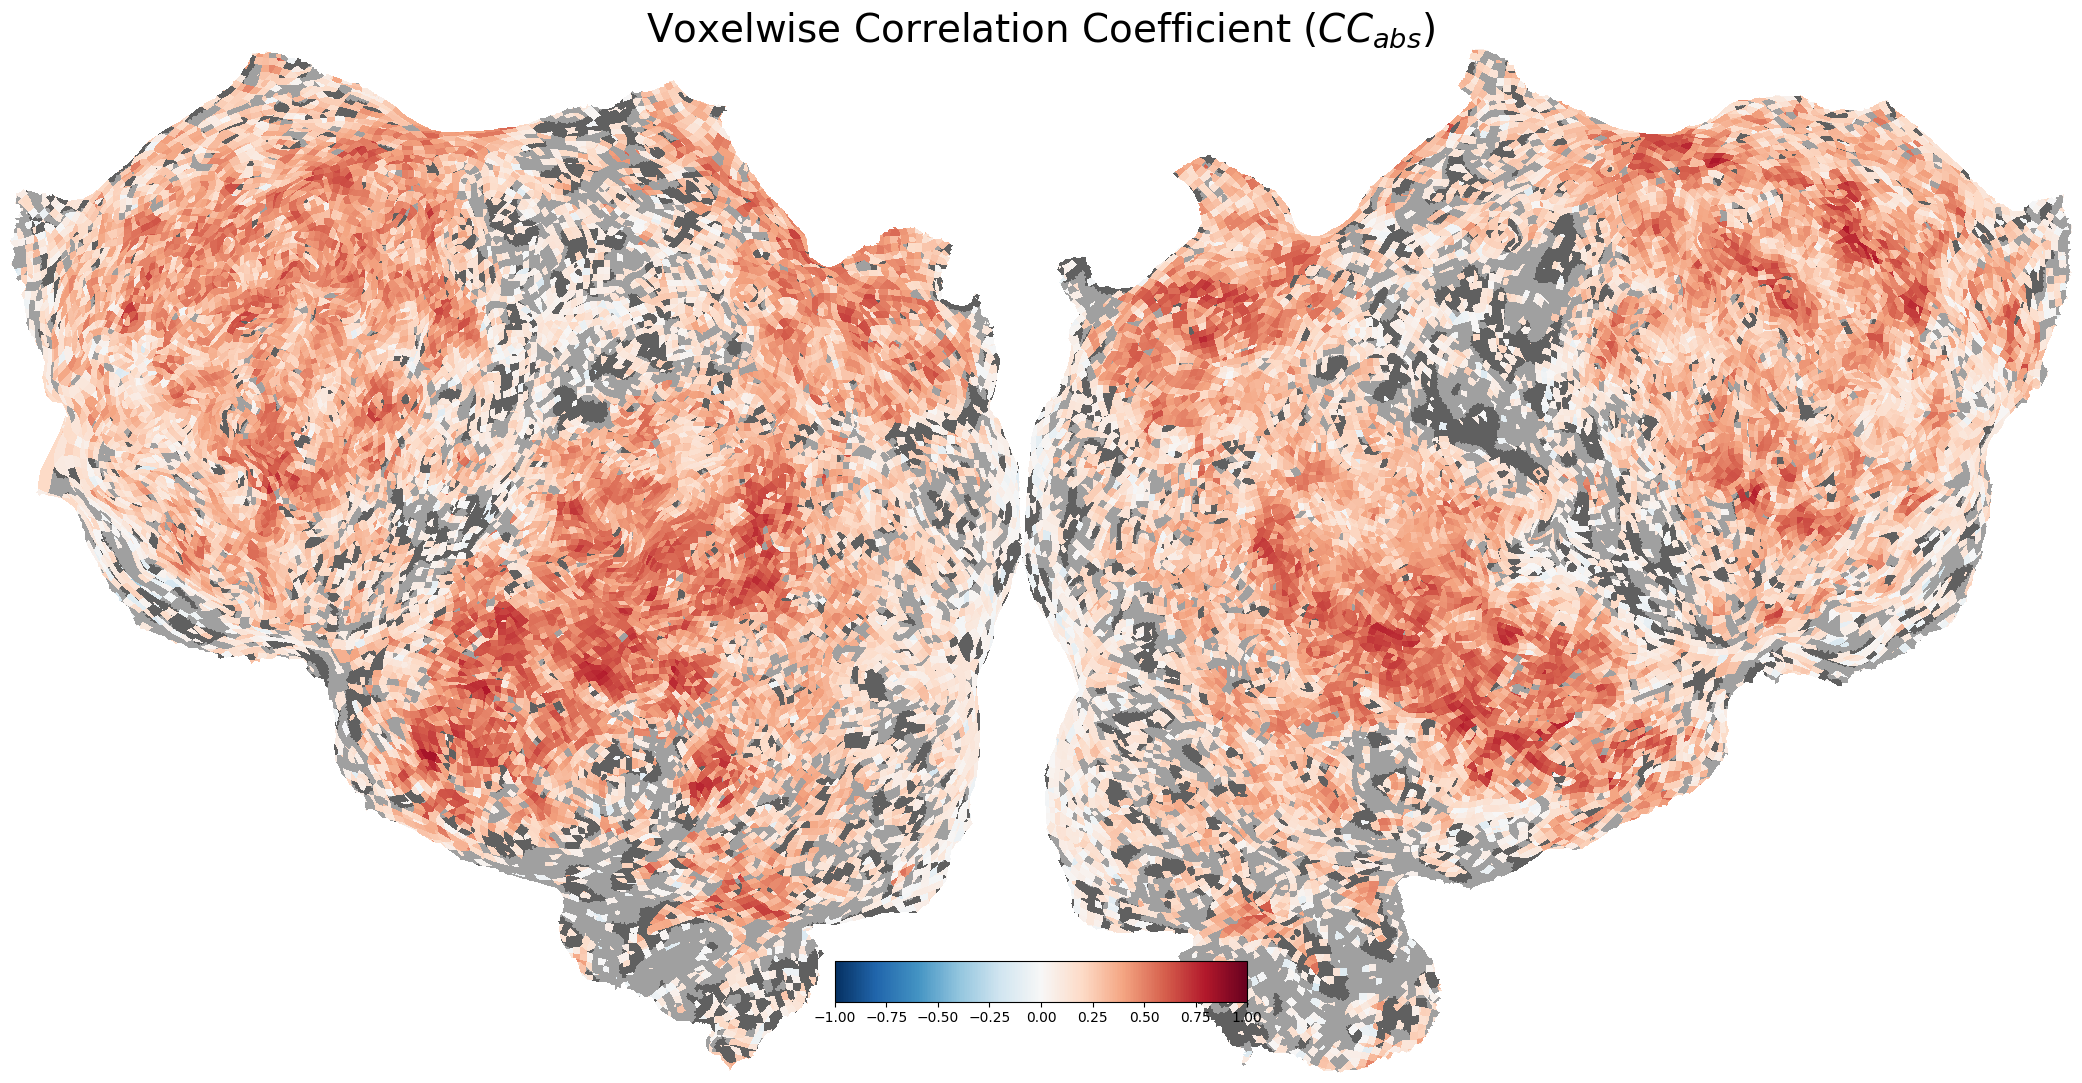

In [11]:
acc = []
for ei, i in enumerate(cc_max):
    if i <= 0.35:
        acc.append(np.nan)
    else:
        acc.append(corrs_unnorm[ei])
acc = np.array(acc)

vol = cortex.Volume(acc, 'AA', '20180905AA-sg-auto', vmin=-1, vmax=1)
cortex.quickshow(vol, with_colorbar=True, linewidth=4, thick=1, with_curvature=True, with_rois=False)
plt.title("Voxelwise Correlation Coefficient ($CC_{abs}$)", size=28);

In [18]:
import cortex
import inspect

We can also plot the regions in cortex that have the most room for improvement based on the noise ceiling, like so:

In [13]:
acc = []
acc2 = []
for ei, i in enumerate(cc_max):
    if i <= 0.35:
        acc.append(np.nan)
        acc2.append(np.nan)
    else:
        acc.append(cc_max[ei] - corrs_unnorm[ei])
        acc2.append(cc_max[ei])
acc = np.array(acc)
acc2 = np.array(acc2)

corr2d = cortex.Volume2D(acc, acc2, 'UTS03', 'UTS03', vmin=0, vmax=0.5, vmin2=0.2, vmax2=0.7,
                        cmap="plasma_alpha")
cortex.quickshow(corr2d, with_curvature=True, with_labels=False,  with_rois=False, linewidth=5, with_colorbar=False);
plt.title("Room for Improvement ($CC_{max}$ - $CC_{abs}$) vs. $CC_{max}$", size=28);

AttributeError: module 'cortex' has no attribute 'Volume2D'

We can also look at individual voxelwise timecourses and see how well we were able to predict them. Here's one voxel from this individual's right precuneus that we presented in our paper.

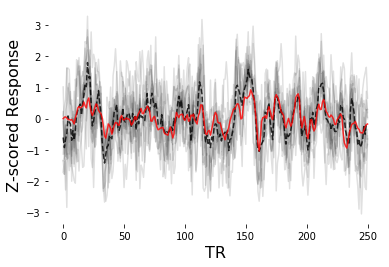

In [6]:
fig, ax1 = plt.subplots(figsize=(6,4))
data = [i.T[55879] for i in tensessions[:,40:,:]]

for i in tensessions[:,40:,:]:
    plt.plot(i.T[55879], alpha=0.12, color='black')
mean_data = np.mean(data, axis=0)
plt.plot(mean_data, 'k--', alpha=0.8)
plt.plot(pred.T[55879], color='red', alpha=0.8)
plt.xlabel("TR", size=16)
plt.ylabel("Z-scored Response", size=16)
ax1.spines['right'].set_visible(False)
ax1.spines['top'].set_visible(False)
ax1.spines['left'].set_visible(False)
ax1.spines['bottom'].set_visible(False)

## Stacked Encoding Model

Next, we will show how to use the joint speech and semantic stacked encoding model, based on [Lin et al.](https://pubmed.ncbi.nlm.nih.gov/37163111/). We start by taking the layerwise residual covariance matrix $\mathcal{R}$, which has been provided, and solving the quadratic program given in the paper. The resulting output gives us a set of attributions $\alpha^{v}$, stored in `acc_alphas`, per voxel.

In [7]:
def quadratic_program_solver(R):
    k = len(R)
    
    P = matrix(np.array(R))
    q = matrix(np.zeros(k))
    
    # alpha_j ≥ 0 Constraint
    G = matrix(-np.eye(k))  
    h = matrix(np.zeros(k)) 

    # sum(alpha_j) = 1 Constraint
    A = matrix(np.ones((1, k))) 
    b = matrix(np.ones(1)) 

    # Solve the quadratic program
    solvers.options['show_progress'] = False
    solution = solvers.qp(P, q, G, h, A, b)

    return np.array(solution['x']).flatten()

# From stacked_regression folder
R = joblib.load("stacked_reg_R_mat_audio_S03.jbl")
R = R[:,1:,1:] # Don't use initial embedding layer, causes attribution issues
acc_alphas = []
for ei, i in enumerate(R):
    alphas = quadratic_program_solver(i)
    acc_alphas.append(alphas)

Next, we compute the final stacked encoding model given by $ \sum_{j=1}^{k} \alpha_{h_j}^{v}  f^{v,s}_{h_j}\left(\boldsymbol{x}_j\right)$. We provide the predictions in several files on the Box for readability, but they can be computed similarly to what was done in the previous section for the OPT weights.

In [8]:
# All loaded files here are from the wheretheressmoke_preds subdirectory of the stacked_regression folder.
acc_alphas = np.array(acc_alphas)
pred = np.zeros((790,NUM_VOX))
for ei, i in enumerate(acc_alphas.T[:16]):
    layer_preds = joblib.load("test_preds_whisper_" + str(2*ei+2) + "_S03.jbl")
    for vox in range(NUM_VOX): 
        pred[:, vox] += layer_preds[:, vox] * acc_alphas[vox][ei]
llama_layer_preds = joblib.load("test_preds_llama30B18_S03.jbl")
for vox in range(NUM_VOX): 
    pred[:, vox] += layer_preds[:, vox] * acc_alphas[vox][16]

We then evaluate our stacked model on some validation data.

In [9]:
# Load the ground truth val/test responses, also from stacked_regression folder
gt =  joblib.load("S03_test_stories_avg_resp.jbl")

stacked_acc_val_stacked = []
for i in range(NUM_VOX):
    stacked_acc_val_stacked.append(np.corrcoef(gt[:,i][251:], pred[:,i][251:])[0][1])

stacked_acc_val_sem = []
for i in range(NUM_VOX):
    stacked_acc_val_sem.append(np.corrcoef(gt[:,i][251:], llama_layer_preds[:,i][251:])[0][1])

We use this validation performance to generate a validation mask which we then use to decide which voxels use the stacked predictions instead of the semantic model predictions.

In [10]:
stacked_acc_test_stacked = []
stacked_acc_test_sem = []
val_mask = np.array(stacked_acc_val_stacked) - np.array(stacked_acc_val_sem) > 0.05
for i in range(95556):
    if val_mask[i]:
        stacked_acc_test_stacked.append(np.corrcoef(gt[:,i][:251], pred[:,i][:251])[0][1])
    else:
        stacked_acc_test_stacked.append(np.corrcoef(gt[:,i][:251], llama_layer_preds[:,i][:251])[0][1])
    stacked_acc_test_sem.append(np.corrcoef(gt[:,i][:251], llama_layer_preds[:,i][:251])[0][1])

We can then plot how much better the stacked model is over the semantic model.

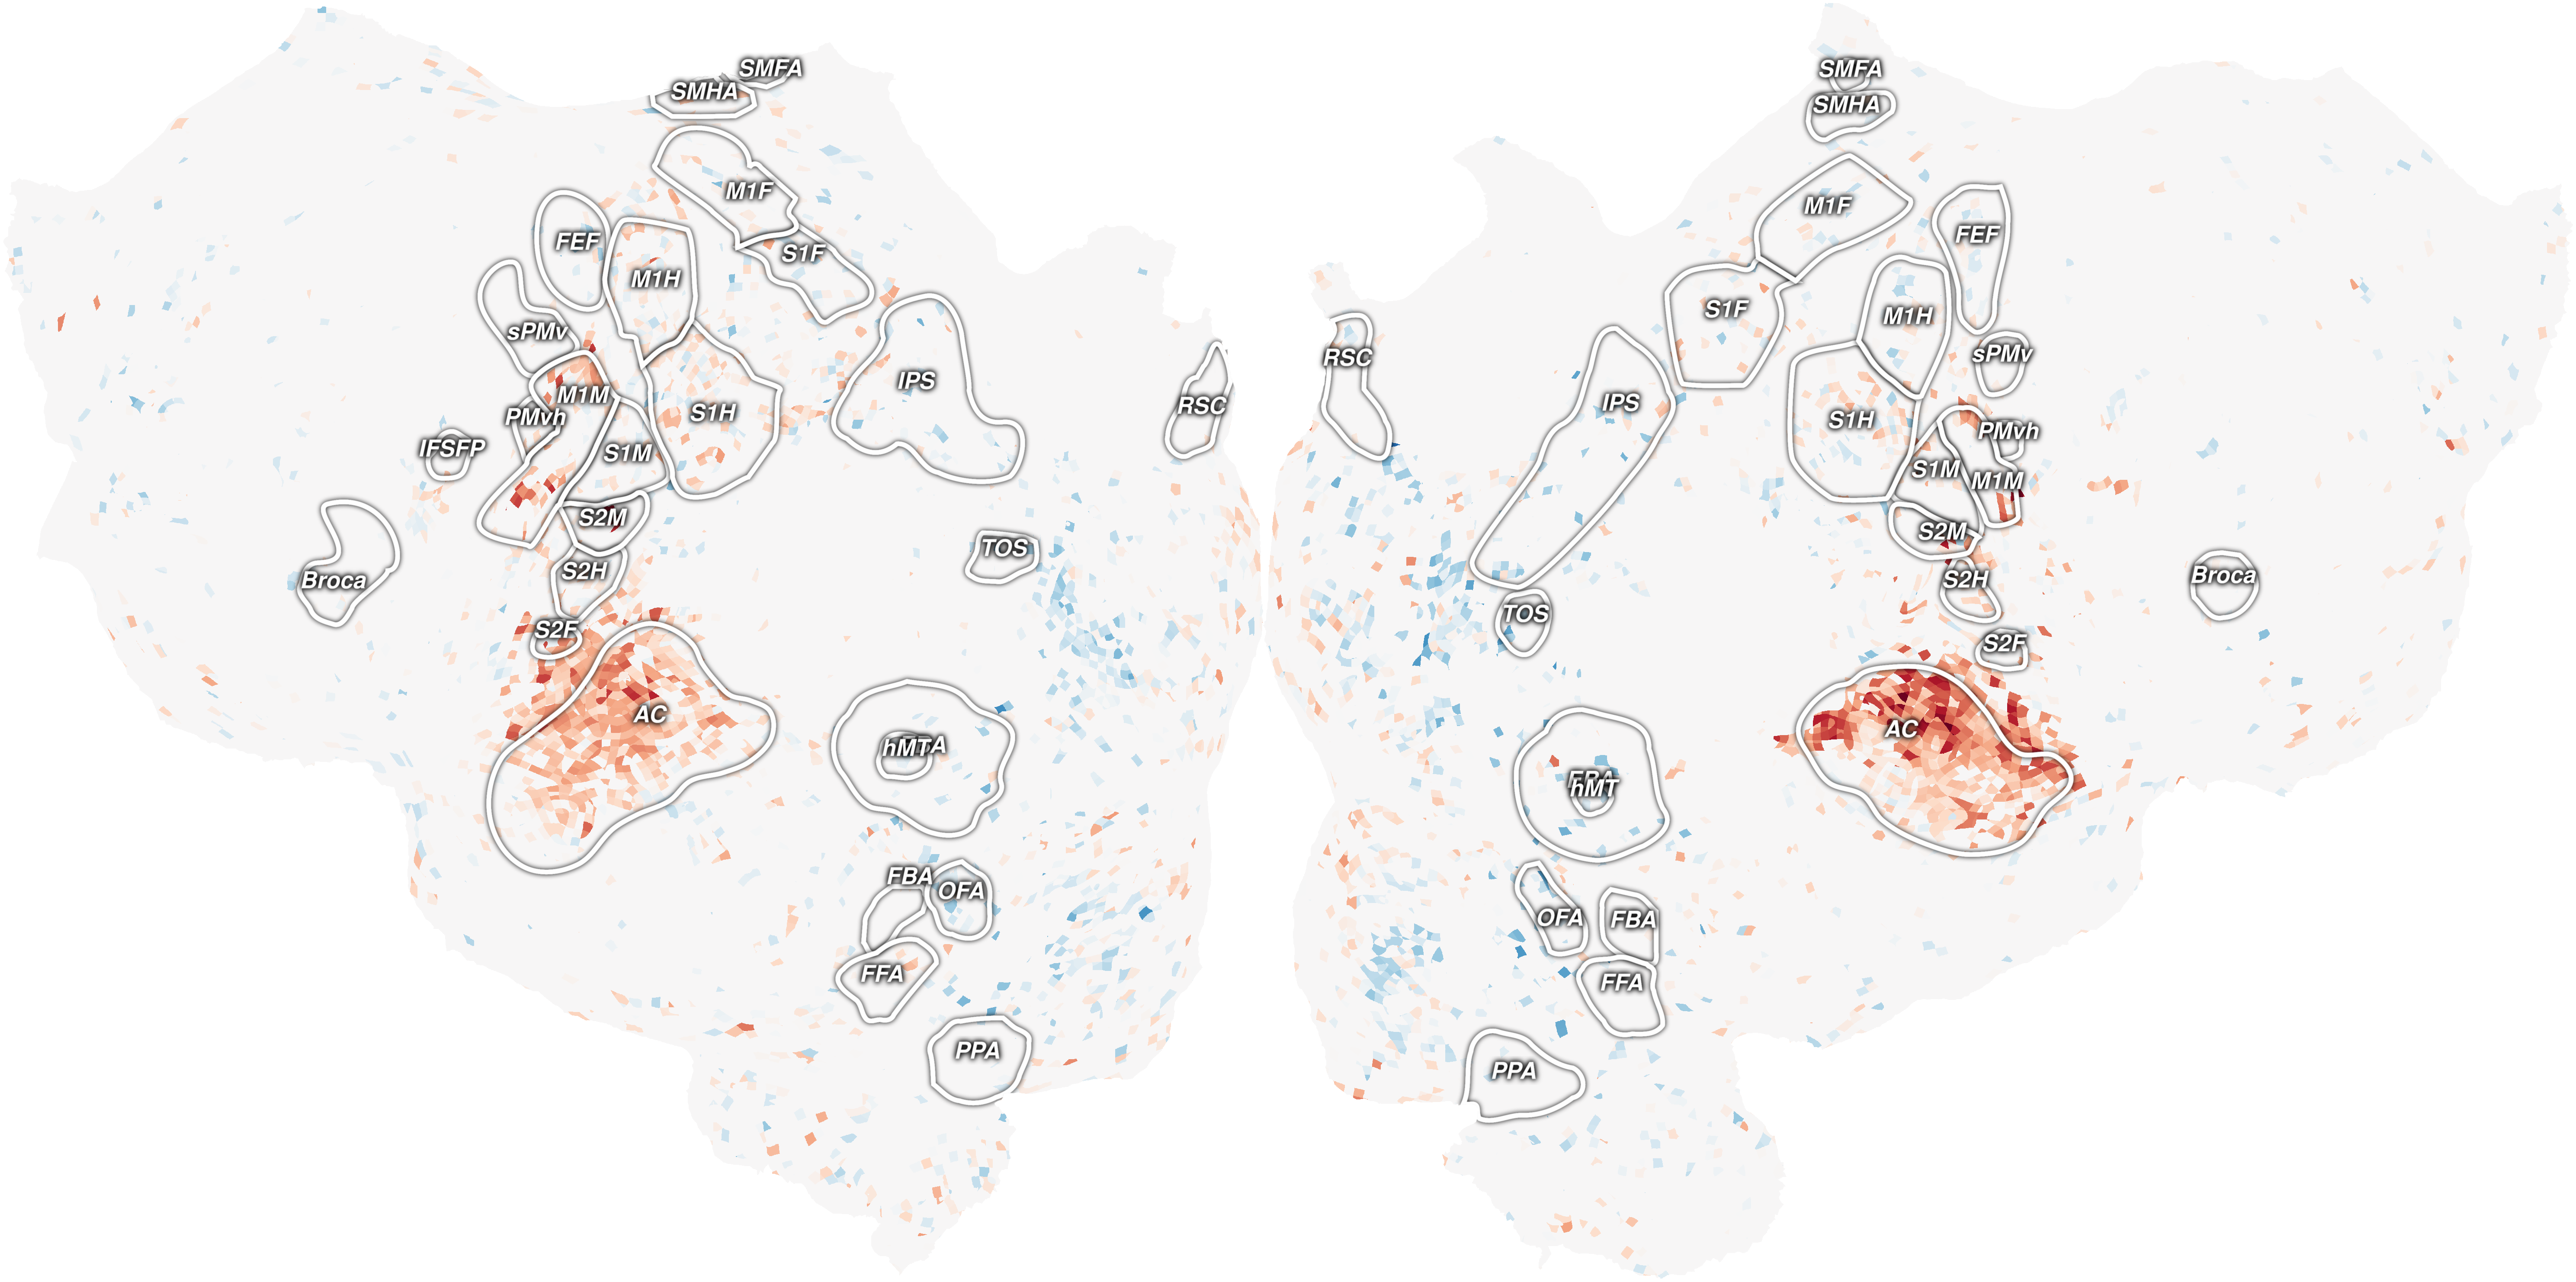

In [11]:
vol = cortex.Volume(np.array(stacked_acc_test_stacked) - np.array(stacked_acc_test_sem), 'UTS03', 'UTS03', vmin=-0.5, vmax=0.5)
cortex.quickshow(vol, with_colorbar=False, linewidth=4, thick=1, with_curvature=True, with_rois=True, height=4096);

We can also plot the convex attributions of the stacked model to see how represetations shift from preferring earlier speech model layers to later speech model layers. This can be visualized by a center-of-mass statistic of the attibution vector.

In [12]:
com = []
for i in range(len(acc_alphas)):
    com_tmp = 0
    for j in range(16):
        com_tmp += j * acc_alphas[i][j]
    com.append(com_tmp)

And now we can plot this center-of-mass statistic on a flatmap.

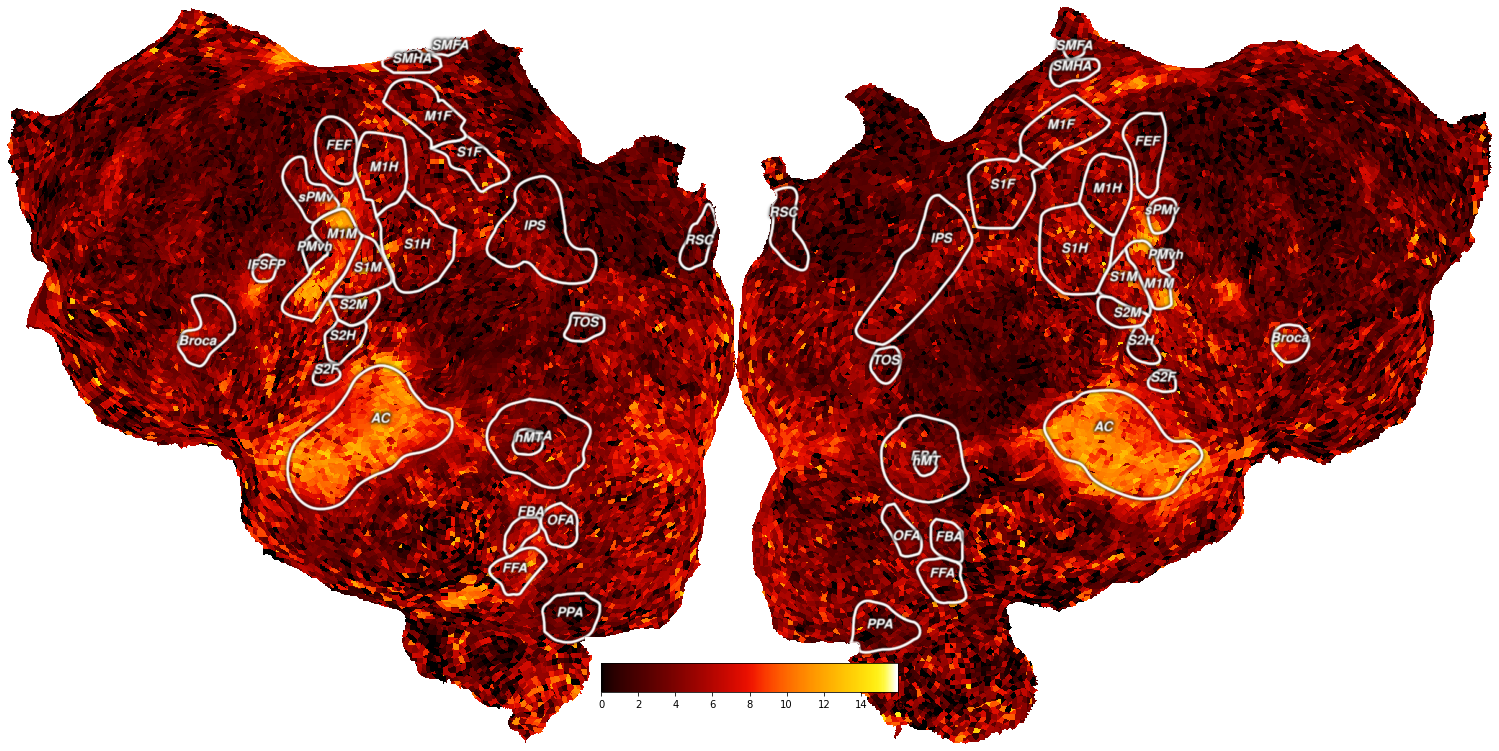

In [13]:
vol = cortex.Volume(np.array(com), 'UTS03', 'UTS03', vmin=0, vmax=16, cmap='fire')
cortex.quickshow(vol, with_colorbar=True, linewidth=4, thick=1, with_curvature=True, with_rois=True);

## Efficient Semantic Feature Extraction

Here we use some code that handles the tedious tokenization aspect of building LLM encoding models with our data. Our dataset is annotated at a per-word level, instead of a per-token level, so efforts need to be made to align the word annotations temporally with the features of the model. This can be done naively by using a fixed-length context window that changes per word, but this is _very slow_. Since we are dealing with large models on a tight computational budget, we want to avoid pointless recomputation as much as possible. We do this with a dynamic programming approach to minimize the number of forward passes that we will need to perform during actual feature extraction. Here, we build a set of dictionaries, `text_dict`, `text_dict2` and `text_dict3` that mark which contexts actually need to be run through the model. We use a non-fixed length sliding window which grows and shrinks at fixed intervals to minimize the number of forward passes that are required. The process can then be repeated in reverse to get the hidden state features in the proper order.

In [14]:
#OPT

# These files are located in the story_data folder of the Box
grids = joblib.load("grids_huge.jbl") # Load TextGrids containing story annotations
trfiles = joblib.load("trfiles_huge.jbl") # Load TRFiles containing TR information

# We'll build an encoding model using this set of stories for this tutorial.
train_stories = ['adollshouse', 'adventuresinsayingyes', 'alternateithicatom', 'avatar', 'buck', 'exorcism',
            'eyespy', 'fromboyhoodtofatherhood', 'hangtime', 'haveyoumethimyet', 'howtodraw', 'inamoment',
            'itsabox', 'legacy', 'naked', 'odetostepfather', 'sloth',
            'souls', 'stagefright', 'swimmingwithastronauts', 'thatthingonmyarm', 'theclosetthatateeverything',
            'tildeath', 'undertheinfluence']

test_stories = ["wheretheressmoke"]

# Filter out the other stories for the tutorial
for story in list(grids):
    if story not in (train_stories + test_stories):
        del grids[story]
        del trfiles[story]

# Make datasequence for story
wordseqs = make_word_ds(grids, trfiles)

# We will be using a sliding context window with minimum size 256 words that increases until size 512 words.
tokenizer = AutoTokenizer.from_pretrained("facebook/opt-125m") # Same tokenizer for all sizes

# Make dictionary to align tokens and words
text_dict, text_dict2, text_dict3 = generate_efficient_feat_dicts_opt(wordseqs, tokenizer, 256, 512)


# We are going to use the 125m parameter model for this tutorial, but any size should work 
model = AutoModelForCausalLM.from_pretrained("facebook/opt-125m")

# We will extract features from the 9th layer of the model
LAYER_NUM = 9

start_time = time.time()
for phrase in text_dict2:
    if text_dict2[phrase]:
        inputs = {}
        inputs['input_ids'] = torch.tensor([text_dict[phrase]]).int()
        inputs['attention_mask'] = torch.ones(inputs['input_ids'].shape)
        out = list(model(**inputs, output_hidden_states=True)[2])
        out = out[LAYER_NUM][0].cpu().detach().numpy()
        out = np.array(out)
        this_key = tuple(inputs['input_ids'][0].cpu().detach().numpy())
        acc_true = 0
        for ei, i in enumerate(this_key):
            if this_key[:ei+1] in text_dict3:
                acc_true += 1
                text_dict3[this_key[:ei+1]] = out[ei,:]
end_time = time.time()

print("Feature extraction took", end_time - start_time, "seconds on", model.device)

# Convert back from dictionary to matrix
feats = convert_to_feature_mats_opt(wordseqs, tokenizer, 256, 512, text_dict3)

AttributeError: module 'torch' has no attribute 'get_default_device'

We can now use these features to create new encoding model weights and test them on some held-out data.

In [5]:
# Same preprocessing as before
# trim off a little more for artifact correction at test time.

#Training data
Rstim = np.nan_to_num(np.vstack([ridge_utils.npp.zs(feats[story][10:-5]) for story in train_stories]))

#Test data
Pstim = np.nan_to_num(np.vstack([ridge_utils.npp.zs(feats[story][trim_start:-trim_end]) for story in test_stories]))

# Add FIR delays
delRstim = make_delayed(Rstim, delays)
delPstim = make_delayed(Pstim, delays)

alphas = np.logspace(1, 4, 15) # Equally log-spaced ridge parameters between 10 and 10000. 
nboots = 3 # Number of cross-validation ridge regression runs. You can lower this number to increase speed.

# Get response data
resp_dict = joblib.load("UTS03_responses.jbl") # Located in story_responses folder
Rresp = np.vstack([resp_dict[story] for story in train_stories])
Presp = np.vstack([resp_dict[story][40:] for story in test_stories])

# Bootstrap chunking parameters
# chunklen = 20
# nchunks = int(len(Rresp) * 0.25 / chunklen)

# # Run ridge regression - this might take some time
# wt, corr, alphas, bscorrs, valinds = bootstrap_ridge(delRstim, Rresp, delPstim, Presp,
#                                                      alphas, nboots, chunklen, nchunks,
#                                                      use_corr=False, single_alpha=False)

In [6]:
np.abs(corr).mean()

NameError: name 'corr' is not defined

And we can plot the resulting test performance...

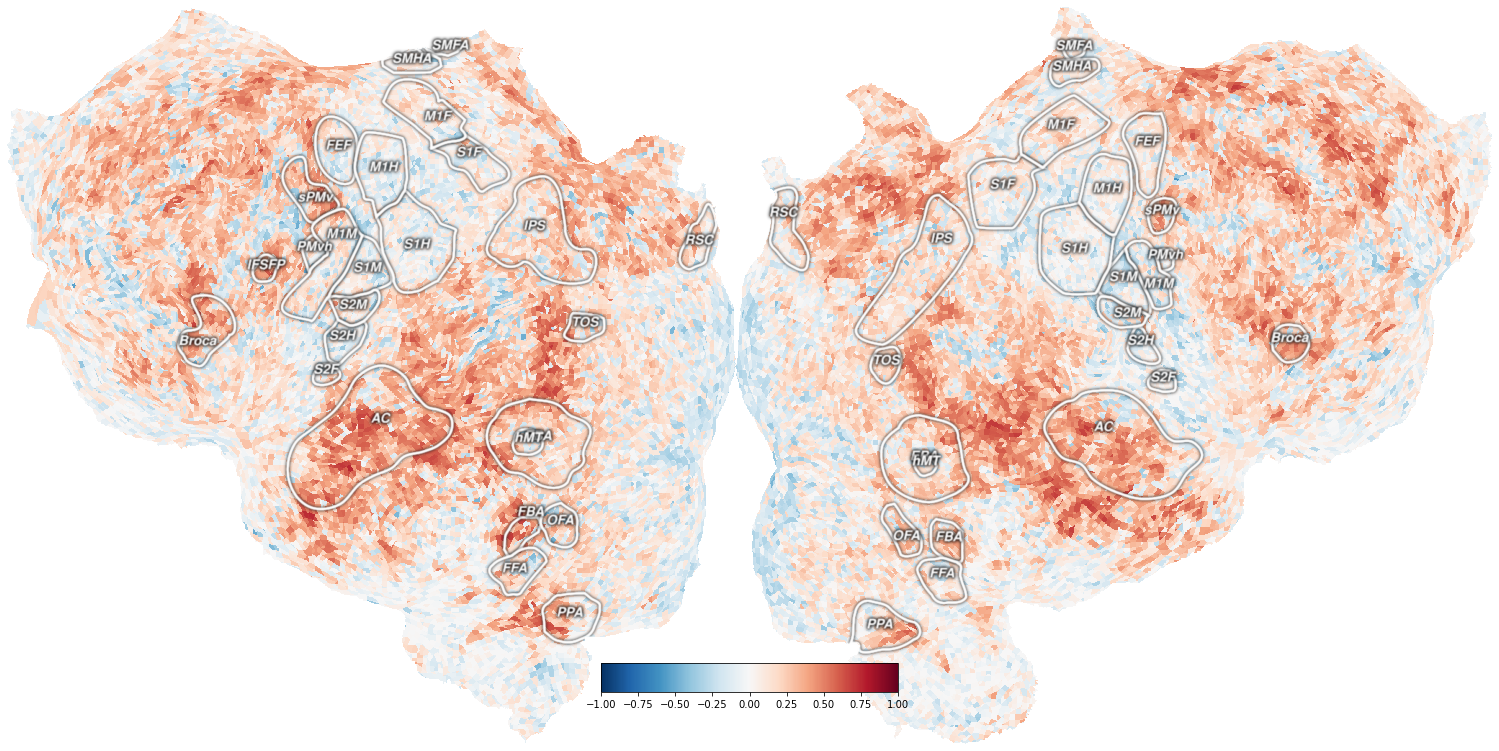

In [16]:
vol = cortex.Volume(np.array(corr), 'UTS03', 'UTS03', vmin=-1, vmax=1, )
cortex.quickshow(vol, with_colorbar=True, linewidth=4, thick=1, with_curvature=True, with_rois=True);

This concludes the tutorial. If you have additional questions about how to use our dataset, or about the paper, feel free to contact rjantonello@utexas.edu. If these data or models were helpful for your own work please cite our paper using the following BibTex citation:

```
@article{antonello2023scaling,
  title={Scaling laws for language encoding models in fMRI}, 
  author={Richard J. Antonello and Aditya R. Vaidya and Alexander G. Huth},
  journal={Advances in Neural Information Processing Systems},
  volume={36},
  year={2023}
}
```

In [14]:
SUBJECT = 'UTS03'

In [15]:
train_stories = ['itsabox', 'odetostepfather', 'inamoment', 'afearstrippedbare', 'findingmyownrescuer', 'hangtime', 'ifthishaircouldtalk', 'goingthelibertyway', 'golfclubbing', 'thetriangleshirtwaistconnection', 'igrewupinthewestborobaptistchurch', 'tetris', 'becomingindian', 'canplanetearthfeedtenbillionpeoplepart1', 'thetiniestbouquet', 'swimmingwithastronauts', 'lifereimagined', 'forgettingfear', 'stumblinginthedark', 'backsideofthestorm', 'food', 'theclosetthatateeverything', 'escapingfromadirediagnosis', 'notontheusualtour', 'exorcism', 'adventuresinsayingyes', 'thefreedomridersandme', 'cocoonoflove', 'waitingtogo', 'thepostmanalwayscalls', 'googlingstrangersandkentuckybluegrass', 'mayorofthefreaks', 'learninghumanityfromdogs', 'shoppinginchina', 'souls', 'cautioneating', 'comingofageondeathrow', 'breakingupintheageofgoogle', 'gpsformylostidentity', 'marryamanwholoveshismother', 'eyespy', 'treasureisland', 'thesurprisingthingilearnedsailingsoloaroundtheworld', 'theadvancedbeginner', 'goldiethegoldfish', 'life', 'thumbsup', 'seedpotatoesofleningrad', 'theshower', 'adollshouse', 'canplanetearthfeedtenbillionpeoplepart2', 'sloth', 'howtodraw', 'quietfire', 'metsmagic', 'penpal', 'thecurse', 'canadageeseandddp', 'thatthingonmyarm', 'buck', 'thesecrettomarriage', 'wildwomenanddancingqueens', 'againstthewind', 'indianapolis', 'alternateithicatom', 'bluehope', 'kiksuya', 'afatherscover', 'haveyoumethimyet', 'firetestforlove', 'catfishingstrangerstofindmyself', 'christmas1940', 'tildeath', 'lifeanddeathontheoregontrail', 'vixenandtheussr', 'undertheinfluence', 'beneaththemushroomcloud', 'jugglingandjesus', 'superheroesjustforeachother', 'sweetaspie', 'naked', 'singlewomanseekingmanwich', 'avatar', 'whenmothersbullyback', 'myfathershands', 'reachingoutbetweenthebars', 'theinterview', 'stagefright', 'legacy', 'canplanetearthfeedtenbillionpeoplepart3', 'listo', 'gangstersandcookies', 'birthofanation', 'mybackseatviewofagreatromance', 'lawsthatchokecreativity', 'threemonths', 'whyimustspeakoutaboutclimatechange', 'leavingbaghdad']
test_stories = ['wheretheressmoke', 'onapproachtopluto', 'fromboyhoodtofatherhood']

In [16]:
# Load in the train features for OPT
delRstim

# Load in the test features for OPT
delPstim

array([[ 0.        ,  0.        ,  0.        , ...,  0.        ,
         0.        ,  0.        ],
       [-1.43630482,  3.00686309, -1.02313322, ...,  0.        ,
         0.        ,  0.        ],
       [-0.18392797,  1.53867143, -1.65154635, ...,  0.        ,
         0.        ,  0.        ],
       ...,
       [ 0.55568965, -0.46542372, -0.26026916, ...,  0.5501676 ,
        -0.56610668, -0.14218444],
       [-0.83731222, -0.0237638 , -0.47416439, ..., -0.2964057 ,
         0.69129922, -0.76810708],
       [ 0.01773479, -0.34942855, -0.86849646, ...,  0.17795891,
        -0.04638256, -0.48948173]])

In [17]:
delRstim.shape

(8673, 3072)

In [18]:
# Load in the train responses for OPT
Rresp

# Load test responses, one story 
Presp

Rresp.shape

(8673, 95556)

In [11]:
import skdim

In [12]:
twonn = skdim.id.TwoNN()
twonn.fit_transform(delRstim)

15.558584077372322

In [22]:
twonn = skdim.id.TwoNN()
twonn.fit_transform(Rresp)

192.1273572237518

In [19]:
# Implement diffusion map
# step 1: project the stim to low dimensions
print('Projecting x')
t = time.time()
dmap = dm.DiffusionMap.from_sklearn(n_evecs = 40, alpha = 0.5, epsilon = 'bgh', k=64) # choosing 40 eigenfunctions bc the ID ~ 40
delRstim_projected = dmap.fit_transform(delRstim)
Mx_train = delRstim_projected
print(f'Ran in {time.time() - t}s')

# step 2: project the response to low dimensions
print('Projecting y')
t = time.time()
dmap_y = dm.DiffusionMap.from_sklearn(n_evecs = 250, alpha = 0.5, epsilon = 'bgh', k=300)
Rresp_projected = dmap_y.fit_transform(Rresp)
My_train = Rresp_projected
print(f'Ran in {time.time() - t}s')

Projecting x
Ran in 10.306314706802368s
Projecting y
Ran in 435.92639923095703s


In [16]:
np.save('My_train.npy', My_train)

In [20]:
# Basic linear regression in X_original, Y_projected space.
linear_model = LinearRegression()
linear_model.fit(delRstim, My_train)

LinearRegression()

In [19]:
print('Evaluating R2')
R2_M = linear_model.score(delRstim, My_train)
print('R2 in fitted space: ', R2_M)

Evaluating R2
R2 in fitted space:  0.34766880411330225


In [17]:
# eval R^2
# Linear regression in X_projected, Y_projected space.
# linear_model = LinearRegression()
# linear_model.fit(Mx_train, My_train)

# print('Evaluating R2 in M space')
# R2_M = linear_model.score(Mx_train, My_train)
# print('R2 in fitted space: ', R2_M)

Evaluating R2 in M space
R2 in fitted space:  2.187529409741096e-06


In [21]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

class UpProjection(nn.Module):
    def __init__(self, input_dim, output_dim, hidden_dims=[500, 1000, 10000]):
        super(UpProjection, self).__init__()
        layers = []
        dims = [input_dim] + hidden_dims + [output_dim]
        
        for i in range(len(dims) - 1):
            layers.append(nn.Linear(dims[i], dims[i+1]))
            if i < len(dims) - 2:  # No activation on the last layer
                layers.append(nn.ReLU())

        self.model = nn.Sequential(*layers)
        self.model = self.model.to('cuda')

    def forward(self, x):
        return self.model(x)

# Training function
def train_model(model, train_dataloader, val_dataloader, epochs=100, lr=1e-3):
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()

    for epoch in range(epochs):
        for x_batch, y_batch in train_dataloader:
            optimizer.zero_grad()
            y_pred = model(x_batch)
            loss = criterion(y_pred, y_batch)
            loss.backward()
            optimizer.step()
        train_bs = x_batch.shape[0]

        if epoch % 10 == 0:
            # Evaluate
            model.eval()
            val_loss = []
            with torch.no_grad():
                for x_batch, y_batch in val_dataloader:
                    y_pred = model(x_batch)
                    loss = criterion(y_pred, y_batch)
                    val_loss.append(loss.item())
            test_bs = x_batch.shape[0]
            val_loss = sum(val_loss) / (test_bs * len(val_loss))
            
            print(f"Epoch {epoch}, Train Loss: {loss.item() / train_bs:.6f}")
            print(f"Epoch {epoch}, Test Loss: {val_loss:.6f}")

            model.train()

In [22]:
# step 4: learn a map from the projected response back up to the original
input_dim = My_train.shape[-1]
output_dim = Rresp.shape[-1]  

My_train = torch.Tensor(My_train).to('cuda')
Rresp = torch.Tensor(Rresp).to('cuda')
train_dataset = TensorDataset(My_train, Rresp)
train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True)

My_test = dmap_y.transform(Presp)
My_test = torch.Tensor(My_test).to('cuda')
Presp = torch.Tensor(Presp).to('cuda')
test_dataset = TensorDataset(My_test, Presp)
test_dataloader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [23]:
model = UpProjection(input_dim, output_dim)
train_model(model, train_dataloader, test_dataloader, epochs=1000)

Epoch 0, Train Loss: 0.165490
Epoch 0, Test Loss: 0.004992
Epoch 10, Train Loss: 1.121467
Epoch 10, Test Loss: 0.040380
Epoch 20, Train Loss: 0.180183
Epoch 20, Test Loss: 0.005566
Epoch 30, Train Loss: 0.171184
Epoch 30, Test Loss: 0.005237
Epoch 40, Train Loss: 0.167695
Epoch 40, Test Loss: 0.005105
Epoch 50, Train Loss: 0.308978
Epoch 50, Test Loss: 0.010317
Epoch 60, Train Loss: 0.188633
Epoch 60, Test Loss: 0.005870
Epoch 70, Train Loss: 0.168292
Epoch 70, Test Loss: 0.005123
Epoch 80, Train Loss: 0.167283
Epoch 80, Test Loss: 0.005085
Epoch 90, Train Loss: 0.166002
Epoch 90, Test Loss: 0.005031
Epoch 100, Train Loss: 0.165420
Epoch 100, Test Loss: 0.004991
Epoch 110, Train Loss: 0.165483
Epoch 110, Test Loss: 0.004991
Epoch 120, Train Loss: 0.165136
Epoch 120, Test Loss: 0.004991
Epoch 130, Train Loss: 0.165671
Epoch 130, Test Loss: 0.004992
Epoch 140, Train Loss: 0.165325
Epoch 140, Test Loss: 0.004991
Epoch 150, Train Loss: 0.165454
Epoch 150, Test Loss: 0.004991
Epoch 160, Tra

Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x14e5fc42e590>>
Traceback (most recent call last):
  File "/home/echeng/miniconda3/envs/neuro/lib/python3.11/site-packages/ipykernel/ipkernel.py", line 770, in _clean_thread_parent_frames
KeyboardInterrupt: 


KeyboardInterrupt: 

In [30]:
model

UpProjection(
  (model): Sequential(
    (0): Linear(in_features=250, out_features=500, bias=True)
    (1): ReLU()
    (2): Linear(in_features=500, out_features=1000, bias=True)
    (3): ReLU()
    (4): Linear(in_features=1000, out_features=10000, bias=True)
    (5): ReLU()
    (6): Linear(in_features=10000, out_features=95556, bias=True)
  )
)

In [24]:
# step 5: evaluate the R^2 in the original space
My_train_hat = torch.Tensor(linear_model.predict(delRstim)).to('cuda')
eval_dataset = TensorDataset(My_train_hat, torch.Tensor(Rresp).to('cuda'))
eval_dataloader = DataLoader(eval_dataset, batch_size=32, shuffle=False)

preds = []

model.eval()
for x_batch, _ in eval_dataloader:
    with torch.no_grad():
        pred = model(x_batch).detach().cpu().numpy()
        preds.append(pred)

In [25]:
pred_ = np.vstack(preds)
pred_.shape

(8673, 95556)

In [26]:
from sklearn.metrics import r2_score

In [ ]:
np.corrcoef(pred_, Rresp.cpu().numpy())

In [ ]:
r2_score(pred_, Rresp.cpu().numpy())

In [37]:
from sklearn.metrics import mean_squared_error
mean_squared_error(Rresp, pred_)

72513.63

In [ ]:
# Test
# step 1: project test stim 
print('Projecting x')
delPstim_projected = dmap.transform(delPstim)

# step 2: project test response
print('Projecting y')
Presp_projected = dmap_y.transform(Presp)

# step 3: apply linear map to reduced X, eval R^2 in reduced space

# step 4: apply inv. map to M and eval R^2 in og space
